# Galerkin Methods

## 1D Poisson equation

We want to use galerkin methods to solve the 1 dimensional poission equation $-u(x)'' = f(x)$ where $f(x)$ is given and we want to solve for $u(x)$. We restrict ourselves to the interval $[-1,1$]$ with Dirichlet boundary conditions $u(0) = 0$ and $u(1) = 0$.

To solve the equation we consider a finite dimensional space of functions $X_0^N$ with basis functions $\{\phi_1, \phi_2, \dots, \phi_n\} \in X_0^N$ which satisfy the boundary condition $\phi_i(\pm1) = 0$. Multiplying the equation we want to solve with some function $\phi_i \in X_0^N$ and multiplying over the domain $\Omega = [-1,1]$ we get
$$- \int_\Omega v(x) \nabla^2 u(x) \mathrm{d}V = \int_\Omega v f \mathrm{d}V$$
After integrating by parts and dropping boundary terms which vanish by assumption we get
$$\int_\Omega \nabla \phi_i(x) \nabla u(x) \mathrm{d}V = \int_\Omega \phi_i f \mathrm{d}V$$

Finding a solution for $u(x)$ we can expand $u(x) = \sum_{j=1}^n u_j \phi_j$ where the coefficients $c_j$ have to be determined. Substituting the expansion into the integral equation we arrive at
$$ \sum_j u_j \int_\Omega \nabla \phi_i(x) \phi_j(x) dV = \int_\Omega \phi_i f dV $$
The integral on the LHS is a matrix $A_{ij}$ and the RHS is a vector $\mathbf{b}$. Thus $A \mathbf{c} = \mathbf{b}$. Solving this linear equation for the vector $\mathbf{c}$ yields the approxmation of $u(x)$.

To make progress we split the interval $\Omega = [-1,1]$ into $n$ subintervals $[x_i, x_{i+1}]$. As a set of basis functions we choose the compactly supported hat functions which are defined as

$$
\phi_i(x) =
\begin{cases}
\frac{x - x_i}{x_{i-1} - x_i} & x \in [x_{i-1}, x_i]  \\
\frac{x_{i+1} - x}{x_i - x_{i+1}} & x \in [x_i, x_{i+1}]
\end{cases}
$$

The product of two functions $q(x) \equiv \phi_i(x) \phi_j(x)$ vanishes if $|i-j|>1$. Therefore the matrix $A_{ij} = 0$ if $|i-j|>1$. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Hat basis functions

We define the nodes and the hat functions with support between only three nodes each

In [2]:
n = 50
nodes = np.linspace(-1, 1, n+1)
nodes_int = nodes[1:-1]             # interior nodes
h = nodes[1] - nodes[0]             # uniform grid

def phi(x, i, nodes, h):
    lower = nodes[i-1]
    mid   = nodes[i]
    upper = nodes[i+1]
    if x > upper or x < lower:
        return 0
    elif x <= mid:
        return (x - lower)/h
    else:
        return (upper - x)/h

In [3]:
print(phi(-1,1,nodes,h))
print(phi(nodes[1],1,nodes,h))
print(phi(nodes[2],1,nodes,h))

0.0
1.0
0.0


## Stiffness matrix A

We need to compute the $n-1 \times n-1$ stiffness matrix $A_{ij}$

$$A_{ij} = \int_{-1}^1 \phi_i'(x) \phi_j'(x) \mathrm{d}x$$

The derivative of $\phi_i(x)$ is $1/h$ and $-1/h$ on the first or second node interval. Therefore The integral is over to constants. For $i=j$ we get two integrals over $\frac{1}{h^2}$ over the interval $[x_i,x_{i+1}]$ which has length $h$, i.e. the value is $\frac{2}{h}$. For $|i-j|=1$ we have support of the integrand on only one interval where the sign of the integrands differs, therefore we get $-\frac{1}{h}$. All other contributions with $|i-j|>1$ vanish.

In [4]:
m = len(nodes_int)
A = np.zeros((m,m))

for i in range(m):
    for j in range(m):
        if i == j:
            A[i,j] = 2 / h
        if abs(i - j) == 1:
            A[i,j] = -1 / h

## RHS vector

Next we need to compute the vector $\mathbf{b}$ on the RHS of the equation. This involves the projection of the function $f$ onto the basis functions $phi_i(x)$. As a simple test case we use $f = 2$ which has the simple analytic solution $u(x) = 1 - x^2$

In [5]:
f = lambda x: 2.0
deg = 50

b = np.zeros(m)
for i in range(m):
    xs = np.linspace(nodes[i], nodes[i+2], deg)
    vals = np.zeros(deg)
    for j in range(deg):
        vals[j] = phi(xs[j],i+1,nodes,h) * f(xs[j])
    b[i] = np.trapezoid(vals, xs)

## Solving the linear equation $A\mathbf{c} = \mathbf{b}$

In [6]:
u_int = np.linalg.solve(A,b)
u_num = np.concatenate([[0],u_int,[0]])
u_exact = lambda x: 1 - x**2

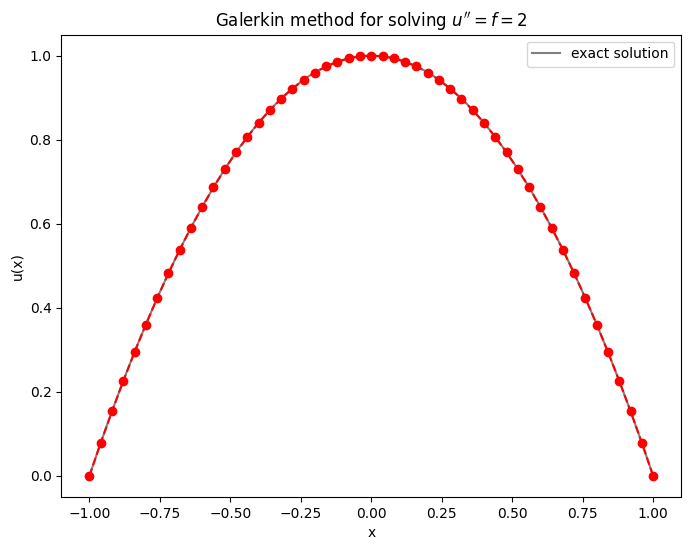

In [7]:
x = np.linspace(-1,1)

plt.figure(figsize=(8,6))
plt.plot(x, u_exact(x), label="exact solution", color="grey")
plt.plot(nodes, u_num, color="red", linestyle="--", marker="o")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title(rf"Galerkin method for solving $u'' = f = 2$")
plt.legend()

## Preiodic function on RHS $f(x) = \pi^2 \sin(\pi x)$

In [8]:
f           = lambda x: np.pi**2 * np.sin(np.pi * x)
u_exact     = lambda x: np.sin(np.pi * x)

deg = 50

b = np.zeros(m)
for i in range(m):
    xs = np.linspace(nodes[i], nodes[i+2], deg)
    vals = np.zeros(deg)
    for j in range(deg):
        vals[j] = phi(xs[j],i+1,nodes,h) * f(xs[j])
    b[i] = np.trapezoid(vals, xs)

In [9]:
u_int = np.linalg.solve(A,b)
u_num = np.concatenate([[0],u_int,[0]])

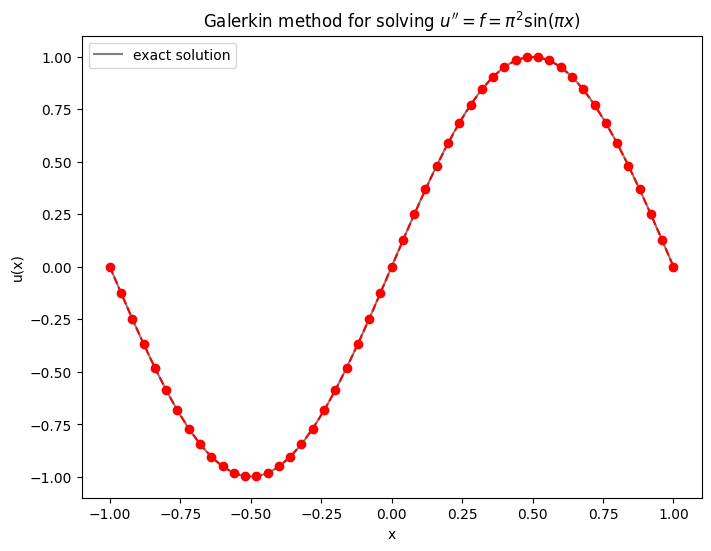

In [10]:
x = np.linspace(-1,1)

plt.figure(figsize=(8,6))
plt.plot(x, u_exact(x), label="exact solution", color="grey")
plt.plot(nodes, u_num, color="red", linestyle="--", marker="o")
plt.xlabel("x")
plt.ylabel("u(x)")
plt.title(rf"Galerkin method for solving $u'' = f = \pi^2 \sin(\pi x)$")
plt.legend()

In [11]:
# n: number of basis functions
# f: function on RHS
# u_exact: exact solution if existing
def solve_poisson(n, f, u_exact):
    # grid
    nodes = np.linspace(-1, 1, n+1)
    nodes_int = nodes[1:-1]             # interior nodes
    h = nodes[1] - nodes[0]             # uniform grid

    # assemble matrix A
    m = len(nodes_int)
    A = np.zeros((m,m))

    for i in range(m):
        for j in range(m):
            if i == j:
                A[i,j] = 2 / h
            if abs(i - j) == 1:
                A[i,j] = -1 / h
                
    # assemble vector b
    deg = 1000

    b = np.zeros(m)
    for i in range(m):
        xs = np.linspace(nodes[i], nodes[i+2], deg)
        vals = np.zeros(deg)
        for j in range(deg):
            vals[j] = phi(xs[j],i+1,nodes,h) * f(xs[j])
        b[i] = np.trapezoid(vals, xs)

    # solve
    u_int = np.linalg.solve(A,b)
    u_num = np.concatenate([[0],u_int,[0]])

    errors = np.abs(u_num - u_exact(nodes))
    l2_error = np.sqrt(np.trapezoid((u_num - u_exact(nodes))**2, nodes))

    # return
    return u_num, errors, l2_error

## Error analysis

In [12]:
f           = lambda x: 12*x**2
u_exact     = lambda x: - x**4 + 1

n_vals      = [4, 6, 8, 12, 16, 24, 32]

u_nums      = []
errors      = []
max_error   = []
l2_errors   = []

for n in n_vals:
    u_num, error, l2_error = solve_poisson(n, f, u_exact)
    u_nums.append(u_num)
    errors.append(error)
    max_error.append(np.max(error))
    l2_errors.append(l2_error)

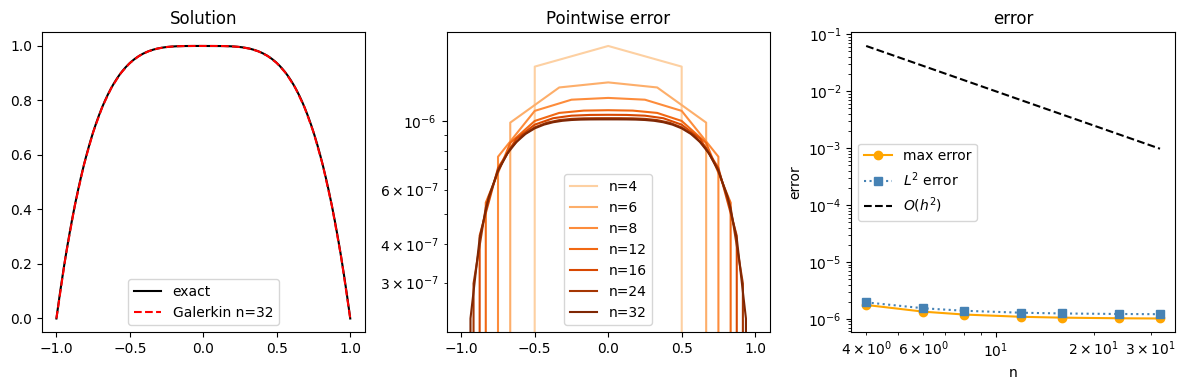

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

colors = plt.cm.Oranges(np.linspace(0.25, 1, len(n_vals)))

# Left: solution for largest n
n = n_vals[-1]
nodes = np.linspace(-1, 1, n+1)
x_fine = np.linspace(-1, 1, 400)
axes[0].plot(x_fine, u_exact(x_fine), 'k-', label='exact')
axes[0].plot(nodes, u_nums[-1], '--', label=f'Galerkin n={n}', color="red")
axes[0].legend()
axes[0].set_title('Solution')

# Right: pointwise error for each n
for i, n in enumerate(n_vals):
    nodes = np.linspace(-1, 1, n+1)
    axes[1].plot(nodes, errors[i], label=f'n={n}', color=colors[i])
axes[1].legend()
axes[1].set_yscale("log")
axes[1].set_title('Pointwise error')

axes[2].loglog(n_vals, max_error, 'o-', color='orange', label='max error')
axes[2].loglog(n_vals, l2_errors, 's:', color='steelblue', label='$L^2$ error')
axes[2].loglog(n_vals, 1/np.array(n_vals)**2, 'k--', label='$O(h^2)$')
axes[2].set_xlabel('n')
axes[2].set_ylabel('error')
axes[2].legend()
axes[2].set_title('error')


plt.tight_layout()
plt.show()

In [14]:
k = 1

f           = lambda x: (k*np.pi)**2 * np.sin(k * np.pi * x)
u_exact     = lambda x: np.sin(k * np.pi * x)

n_vals      = [4, 6, 8, 12, 16, 24, 32]

u_nums      = []
errors      = []
max_error   = []
l2_errors   = []

for n in n_vals:
    u_num, error, l2_error = solve_poisson(n, f, u_exact)
    u_nums.append(u_num)
    errors.append(error)
    max_error.append(np.max(error))
    l2_errors.append(l2_error)

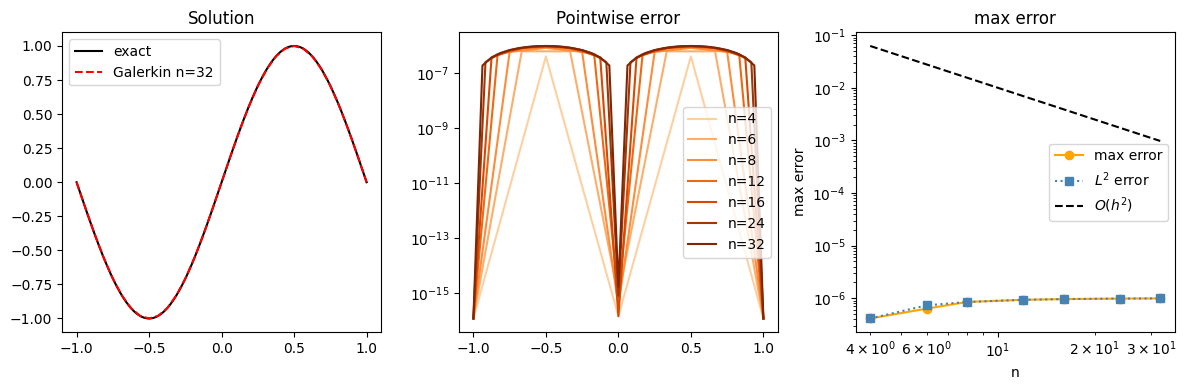

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

colors = plt.cm.Oranges(np.linspace(0.25, 1, len(n_vals)))

# Left: solution for largest n
n = n_vals[-1]
nodes = np.linspace(-1, 1, n+1)
x_fine = np.linspace(-1, 1, 400)
axes[0].plot(x_fine, u_exact(x_fine), 'k-', label='exact')
axes[0].plot(nodes, u_nums[-1], '--', label=f'Galerkin n={n}', color="red")
axes[0].legend()
axes[0].set_title('Solution')

# Right: pointwise error for each n
for i, n in enumerate(n_vals):
    nodes = np.linspace(-1, 1, n+1)
    axes[1].plot(nodes, errors[i], label=f'n={n}', color=colors[i])
axes[1].legend()
axes[1].set_yscale("log")
axes[1].set_title('Pointwise error')

axes[2].loglog(n_vals, max_error, 'o-', color='orange', label='max error')
axes[2].loglog(n_vals, l2_errors, 's:', color='steelblue', label='$L^2$ error')
axes[2].loglog(n_vals, 1/np.array(n_vals)**2, 'k--', label='$O(h^2)$')
axes[2].set_xlabel('n')
axes[2].set_ylabel('max error')
axes[2].legend()
axes[2].set_title('max error')

plt.tight_layout()
plt.show()

In [16]:
k = 2

f           = lambda x: (k*np.pi)**2 * np.sin(k * np.pi * x)
u_exact     = lambda x: np.sin(k * np.pi * x)

n_vals      = [4, 6, 8, 12, 16, 24, 32]

u_nums      = []
errors      = []
max_error   = []
l2_errors   = []

for n in n_vals:
    u_num, error, l2_error = solve_poisson(n, f, u_exact)
    u_nums.append(u_num)
    errors.append(error)
    max_error.append(np.max(error))
    l2_errors.append(l2_error)

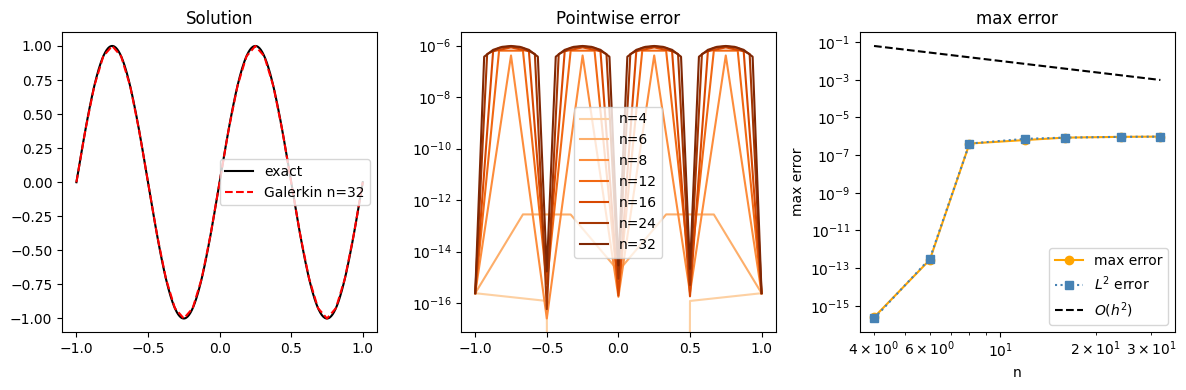

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

colors = plt.cm.Oranges(np.linspace(0.25, 1, len(n_vals)))

# Left: solution for largest n
n = n_vals[-1]
nodes = np.linspace(-1, 1, n+1)
x_fine = np.linspace(-1, 1, 400)
axes[0].plot(x_fine, u_exact(x_fine), 'k-', label='exact')
axes[0].plot(nodes, u_nums[-1], '--', label=f'Galerkin n={n}', color="red")
axes[0].legend()
axes[0].set_title('Solution')

# Right: pointwise error for each n
for i, n in enumerate(n_vals):
    nodes = np.linspace(-1, 1, n+1)
    axes[1].plot(nodes, errors[i], label=f'n={n}', color=colors[i])
axes[1].legend()
axes[1].set_yscale("log")
axes[1].set_title('Pointwise error')

axes[2].loglog(n_vals, max_error, 'o-', color='orange', label='max error')
axes[2].loglog(n_vals, l2_errors, 's:', color='steelblue', label='$L^2$ error')
axes[2].loglog(n_vals, 1/np.array(n_vals)**2, 'k--', label='$O(h^2)$')
axes[2].set_xlabel('n')
axes[2].set_ylabel('max error')
axes[2].legend()
axes[2].set_title('max error')

plt.tight_layout()
plt.show()

In [18]:
k = 8

f           = lambda x: (k*np.pi)**2 * np.sin(k * np.pi * x)
u_exact     = lambda x: np.sin(k * np.pi * x)

n_vals      = [4, 6, 8, 12, 16, 24, 32, 64]

u_nums      = []
errors      = []
max_error   = []
l2_errors   = []

for n in n_vals:
    u_num, error, l2_error = solve_poisson(n, f, u_exact)
    u_nums.append(u_num)
    errors.append(error)
    max_error.append(np.max(error))
    l2_errors.append(l2_error)

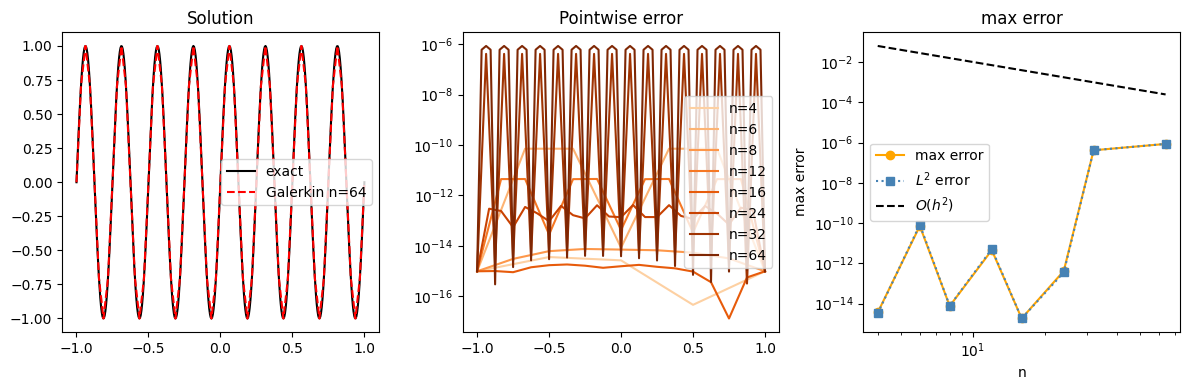

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

colors = plt.cm.Oranges(np.linspace(0.25, 1, len(n_vals)))

# Left: solution for largest n
n = n_vals[-1]
nodes = np.linspace(-1, 1, n+1)
x_fine = np.linspace(-1, 1, 400)
axes[0].plot(x_fine, u_exact(x_fine), 'k-', label='exact')
axes[0].plot(nodes, u_nums[-1], '--', label=f'Galerkin n={n}', color="red")
axes[0].legend()
axes[0].set_title('Solution')

# Right: pointwise error for each n
for i, n in enumerate(n_vals):
    nodes = np.linspace(-1, 1, n+1)
    axes[1].plot(nodes, errors[i], label=f'n={n}', color=colors[i])
axes[1].legend()
axes[1].set_yscale("log")
axes[1].set_title('Pointwise error')

axes[2].loglog(n_vals, max_error, 'o-', color='orange', label='max error')
axes[2].loglog(n_vals, l2_errors, 's:', color='steelblue', label='$L^2$ error')
axes[2].loglog(n_vals, 1/np.array(n_vals)**2, 'k--', label='$O(h^2)$')
axes[2].set_xlabel('n')
axes[2].set_ylabel('max error')
axes[2].legend()
axes[2].set_title('max error')

plt.tight_layout()
plt.show()

In [20]:
f           = lambda x: -np.exp(x)
u_exact     = lambda x: np.exp(x) - x * np.sinh(1) - np.cosh(1)

n_vals      = [4, 6, 8, 12, 16, 24, 32]

u_nums      = []
errors      = []
max_error   = []
l2_errors   = []

for n in n_vals:
    u_num, error, l2_error = solve_poisson(n, f, u_exact)
    u_nums.append(u_num)
    errors.append(error)
    max_error.append(np.max(error))
    l2_errors.append(l2_error)

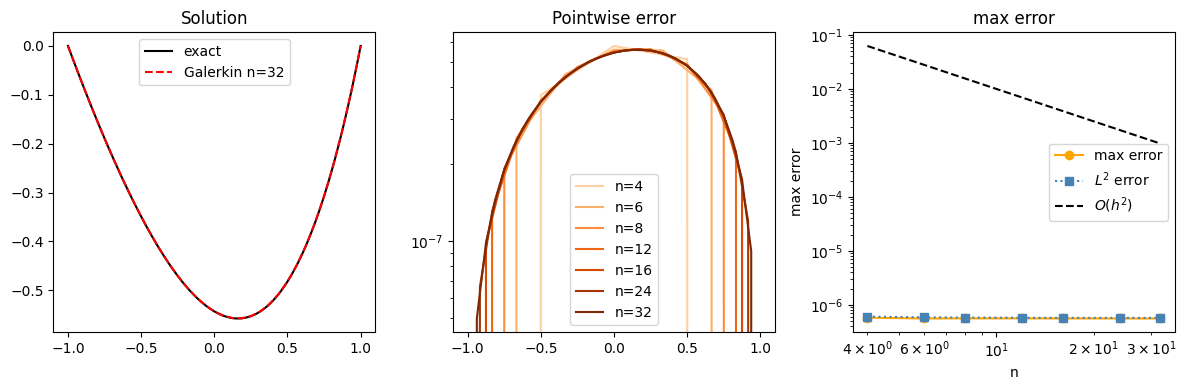

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

colors = plt.cm.Oranges(np.linspace(0.25, 1, len(n_vals)))

# Left: solution for largest n
n = n_vals[-1]
nodes = np.linspace(-1, 1, n+1)
x_fine = np.linspace(-1, 1, 400)
axes[0].plot(x_fine, u_exact(x_fine), 'k-', label='exact')
axes[0].plot(nodes, u_nums[-1], '--', label=f'Galerkin n={n}', color="red")
axes[0].legend()
axes[0].set_title('Solution')

# Right: pointwise error for each n
for i, n in enumerate(n_vals):
    nodes = np.linspace(-1, 1, n+1)
    axes[1].plot(nodes, errors[i], label=f'n={n}', color=colors[i])
axes[1].legend()
axes[1].set_yscale("log")
axes[1].set_title('Pointwise error')

axes[2].loglog(n_vals, max_error, 'o-', color='orange', label='max error')
axes[2].loglog(n_vals, l2_errors, 's:', color='steelblue', label='$L^2$ error')
axes[2].loglog(n_vals, 1/np.array(n_vals)**2, 'k--', label='$O(h^2)$')
axes[2].set_xlabel('n')
axes[2].set_ylabel('max error')
axes[2].legend()
axes[2].set_title('max error')

plt.tight_layout()
plt.show()

In [22]:
eps = 0.1

f           = lambda x: 1/((x-0.5)**2 + eps**2)
u_exact     = lambda x: np.exp(x) - x * np.sinh(1) - np.cosh(1)

n_vals      = [4, 6, 8, 12, 16, 24, 32]

u_nums      = []
errors      = []
max_error   = []
l2_errors   = []

n_ref = 2000
u_ref, _, _ = solve_poisson(n_ref, f, lambda x: np.zeros_like(x))
nodes_ref = np.linspace(-1, 1, n_ref + 1)

for n in n_vals:
    nodes = np.linspace(-1, 1, n + 1)
    u_num, _, _ = solve_poisson(n, f, lambda x: np.zeros_like(x))
    u_ref_interp = np.interp(nodes, nodes_ref, u_ref)
    error = np.abs(u_num - u_ref_interp)
    l2 = np.sqrt(np.trapezoid((u_num - u_ref_interp)**2, nodes))
    u_nums.append(u_num)
    errors.append(error)
    max_error.append(np.max(error))
    l2_errors.append(l2)

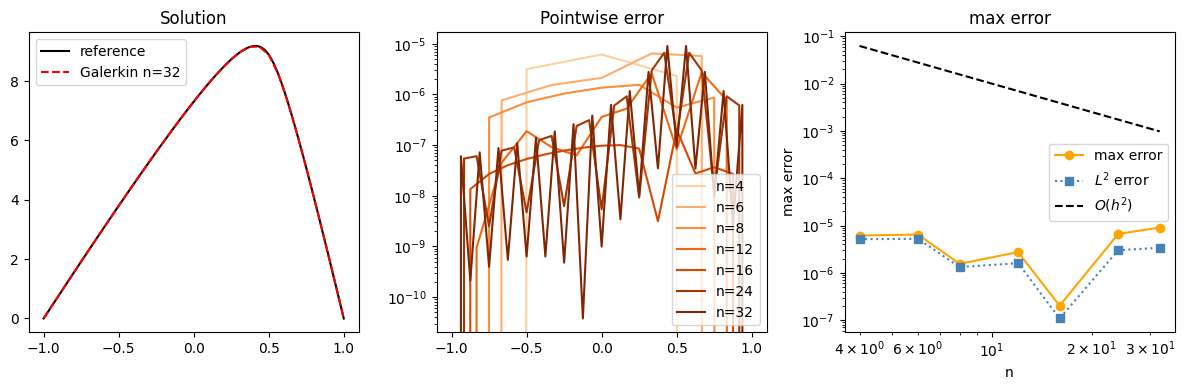

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

colors = plt.cm.Oranges(np.linspace(0.25, 1, len(n_vals)))

# Left: solution for largest n
n = n_vals[-1]
nodes = np.linspace(-1, 1, n+1)
u_ref_fine = np.interp(x_fine, nodes_ref, u_ref)
axes[0].plot(x_fine, u_ref_fine, 'k-', label='reference')
axes[0].plot(nodes, u_nums[-1], '--', label=f'Galerkin n={n}', color="red")
axes[0].legend()
axes[0].set_title('Solution')

# Right: pointwise error for each n
for i, n in enumerate(n_vals):
    nodes = np.linspace(-1, 1, n+1)
    axes[1].plot(nodes, errors[i], label=f'n={n}', color=colors[i])
axes[1].legend()
axes[1].set_yscale("log")
axes[1].set_title('Pointwise error')

axes[2].loglog(n_vals, max_error, 'o-', color='orange', label='max error')
axes[2].loglog(n_vals, l2_errors, 's:', color='steelblue', label='$L^2$ error')
axes[2].loglog(n_vals, 1/np.array(n_vals)**2, 'k--', label='$O(h^2)$')
axes[2].set_xlabel('n')
axes[2].set_ylabel('max error')
axes[2].legend()
axes[2].set_title('max error')

plt.tight_layout()
plt.show()

## Helmholtz equation

Next we want to solve the 1D Helmholtz equation: 
$$-u''(x) - k^2 u(x) = f(x)$$
The Galerkin method works quite similiar. From the "strong" form of the equation we can derive the "weak" form with the set of basis funtions which yields
$$\int_\Omega \phi_i' u'  \mathrm{d}x- k^2 \int_\Omega \phi_i u \mathrm{d}x = \int_\Omega \phi_i f \mathrm{d}x$$
In matrix form we again have the matrix $A_{ij}$ but this time there also appears the mass matrix $M_{ij} = \int_\Omega \phi_i \phi_j$, the matrix elements are zero if $|i - j| > 1$. For $i=j$ we get $M_{ii} = \frac{2h}{3}$ from a triangle with basis $2h$ and height 1 squared (one interval is $\int_0^h (x/h)^2 \mathrm{d}x= h/3$). For $|i-j|=1$ we have an overlap only in one interval which gives $\int_0^h \mathrm{d}x = 1/h^2x\cdot(h-x) = h/6$. 

In [24]:
# n: number of basis functions
# f: function on RHS
# u_exact: exact solution if existing
def solve_helmholtz(n, k, f, u_exact):
    # grid
    nodes = np.linspace(-1, 1, n+1)
    nodes_int = nodes[1:-1]             # interior nodes
    h = nodes[1] - nodes[0]             # uniform grid

    # assemble matrix A
    m = len(nodes_int)
    A = np.zeros((m,m))
    M = np.zeros((m,m))

    for i in range(m):
        for j in range(m):
            if i == j:
                A[i,j] = 2 / h
                M[i,j] = 2 * h / 3
            if abs(i - j) == 1:
                A[i,j] = -1 / h
                M[i,j] = h / 6
                
    # assemble vector b
    deg = 1000

    b = np.zeros(m)
    for i in range(m):
        xs = np.linspace(nodes[i], nodes[i+2], deg)
        vals = np.zeros(deg)
        for j in range(deg):
            vals[j] = phi(xs[j],i+1,nodes,h) * f(xs[j])
        b[i] = np.trapezoid(vals, xs)

    # solve
    u_int = np.linalg.solve(A - k**2 * M,b)
    u_num = np.concatenate([[0],u_int,[0]])

    errors = np.abs(u_num - u_exact(nodes))
    l2_error = np.sqrt(np.trapezoid((u_num - u_exact(nodes))**2, nodes))

    # return
    return u_num, errors, l2_error

In [25]:
k = 2

f           = lambda x: (np.pi**2 - k**2) * np.sin(np.pi*x)
u_exact     = lambda x: np.sin(np.pi*x)

n_vals      = [4, 6, 8, 12, 16, 24, 32, 64, 128, 256]

u_nums      = []
errors      = []
max_error   = []
l2_errors   = []

for n in n_vals:
    u_num, error, l2_error = solve_helmholtz(n, k, f, u_exact)
    u_nums.append(u_num)
    errors.append(error)
    max_error.append(np.max(error))
    l2_errors.append(l2_error)

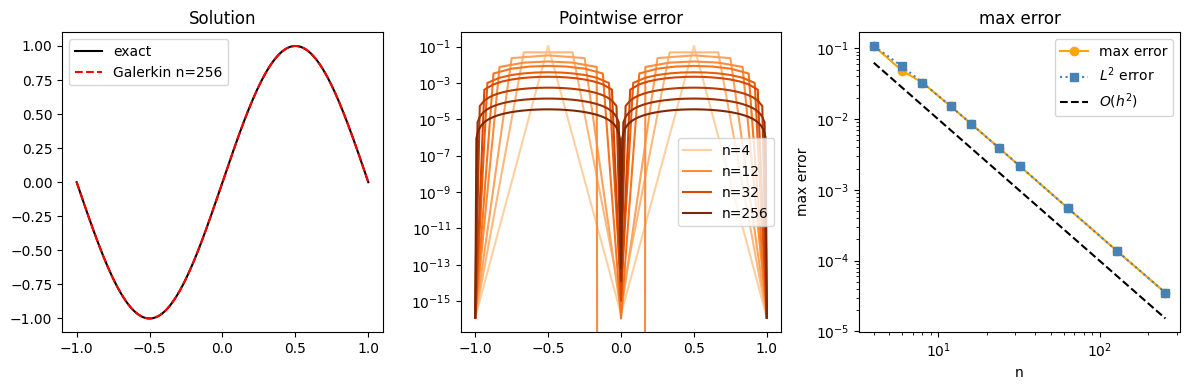

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

colors = plt.cm.Oranges(np.linspace(0.25, 1, len(n_vals)))

# Left: solution for largest n
n = n_vals[-1]
nodes = np.linspace(-1, 1, n+1)
x_fine = np.linspace(-1, 1, 400)
axes[0].plot(x_fine, u_exact(x_fine), 'k-', label='exact')
axes[0].plot(nodes, u_nums[-1], '--', label=f'Galerkin n={n}', color="red")
axes[0].legend()
axes[0].set_title('Solution')

# Right: pointwise error for each n
for i, n in enumerate(n_vals):
    nodes = np.linspace(-1, 1, n+1)
    label = f'n={n}' if i in [0, len(n_vals)//3, 2*len(n_vals)//3, len(n_vals)-1] else None
    axes[1].plot(nodes, errors[i], label=label, color=colors[i])
axes[1].legend()
axes[1].set_yscale("log")
axes[1].set_title('Pointwise error')

axes[2].loglog(n_vals, max_error, 'o-', color='orange', label='max error')
axes[2].loglog(n_vals, l2_errors, 's:', color='steelblue', label='$L^2$ error')
axes[2].loglog(n_vals, 1/np.array(n_vals)**2, 'k--', label='$O(h^2)$')
axes[2].set_xlabel('n')
axes[2].set_ylabel('max error')
axes[2].legend()
axes[2].set_title('max error')

plt.tight_layout()
plt.show()

In [27]:
k = 3.14

f           = lambda x: (np.pi**2 - k**2) * np.sin(np.pi*x)
u_exact     = lambda x: np.sin(np.pi*x)

n_vals      = [4, 6, 8, 12, 16, 24, 32, 64, 128, 256,512,1024,2048]

u_nums      = []
errors      = []
max_error   = []
l2_errors   = []

for n in n_vals:
    u_num, error, l2_error = solve_helmholtz(n, k, f, u_exact)
    u_nums.append(u_num)
    errors.append(error)
    max_error.append(np.max(error))
    l2_errors.append(l2_error)

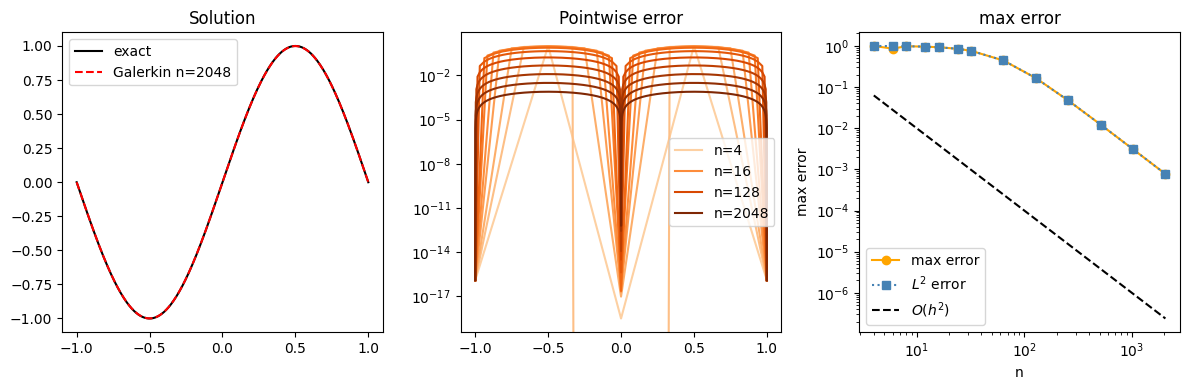

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

colors = plt.cm.Oranges(np.linspace(0.25, 1, len(n_vals)))

# Left: solution for largest n
n = n_vals[-1]
nodes = np.linspace(-1, 1, n+1)
x_fine = np.linspace(-1, 1, 400)
axes[0].plot(x_fine, u_exact(x_fine), 'k-', label='exact')
axes[0].plot(nodes, u_nums[-1], '--', label=f'Galerkin n={n}', color="red")
axes[0].legend()
axes[0].set_title('Solution')

# Right: pointwise error for each n
for i, n in enumerate(n_vals):
    nodes = np.linspace(-1, 1, n+1)
    label = f'n={n}' if i in [0, len(n_vals)//3, 2*len(n_vals)//3, len(n_vals)-1] else None
    axes[1].plot(nodes, errors[i], label=label, color=colors[i])
axes[1].legend()
axes[1].set_yscale("log")
axes[1].set_title('Pointwise error')

axes[2].loglog(n_vals, max_error, 'o-', color='orange', label='max error')
axes[2].loglog(n_vals, l2_errors, 's:', color='steelblue', label='$L^2$ error')
axes[2].loglog(n_vals, 1/np.array(n_vals)**2, 'k--', label='$O(h^2)$')
axes[2].set_xlabel('n')
axes[2].set_ylabel('max error')
axes[2].legend()
axes[2].set_title('max error')

plt.tight_layout()
plt.show()

In [29]:
k = 1

f           = lambda x: 8*np.pi*x*np.cos(2*np.pi*x) + (2 + k**2*(x**2 - 1) - 4*np.pi**2*(x**2 -1))*np.sin(2*np.pi*x)
u_exact     = lambda x: (1-x**2)*np.sin(2*np.pi*x)

n_vals      = [4,8,16,32,64,128,256,512,1024]

u_nums      = []
errors      = []
max_error   = []
l2_errors   = []

for n in n_vals:
    u_num, error, l2_error = solve_helmholtz(n, k, f, u_exact)
    u_nums.append(u_num)
    errors.append(error)
    max_error.append(np.max(error))
    l2_errors.append(l2_error)

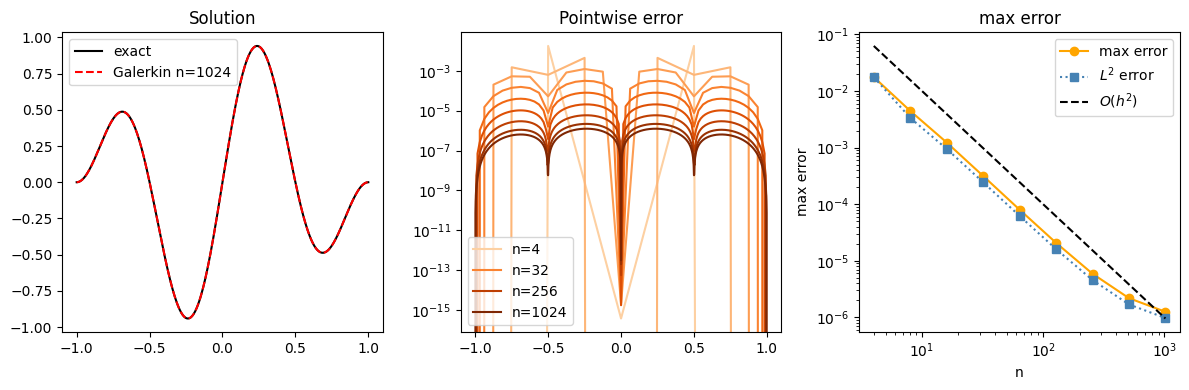

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

colors = plt.cm.Oranges(np.linspace(0.25, 1, len(n_vals)))

# Left: solution for largest n
n = n_vals[-1]
nodes = np.linspace(-1, 1, n+1)
x_fine = np.linspace(-1, 1, 400)
axes[0].plot(x_fine, u_exact(x_fine), 'k-', label='exact')
axes[0].plot(nodes, u_nums[-1], '--', label=f'Galerkin n={n}', color="red")
axes[0].legend()
axes[0].set_title('Solution')

# Right: pointwise error for each n
for i, n in enumerate(n_vals):
    nodes = np.linspace(-1, 1, n+1)
    label = f'n={n}' if i in [0, len(n_vals)//3, 2*len(n_vals)//3, len(n_vals)-1] else None
    axes[1].plot(nodes, errors[i], label=label, color=colors[i])
axes[1].legend()
axes[1].set_yscale("log")
axes[1].set_title('Pointwise error')

axes[2].loglog(n_vals, max_error, 'o-', color='orange', label='max error')
axes[2].loglog(n_vals, l2_errors, 's:', color='steelblue', label='$L^2$ error')
axes[2].loglog(n_vals, 1/np.array(n_vals)**2, 'k--', label='$O(h^2)$')
axes[2].set_xlabel('n')
axes[2].set_ylabel('max error')
axes[2].legend()
axes[2].set_title('max error')

plt.tight_layout()
plt.show()